In [1]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.optimize import least_squares
import surfinBH
import gwsurrogate as gws
import sympy as sp
from IPython.display import display, Math
import lal
from tqdm.auto import tqdm
lal.swig_redirect_standard_output_error(False)

/home/giacomo/Thesis/Entropy-conjecture/.venv/lib/python3.12/site-packages/lalsimulation/_lalsimulation_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lal.MSUN_SI != Msun


True

In [2]:
fit = surfinBH.LoadFits('NRSur7dq4EmriRemnant')
sur_wave_precessing = gws.LoadSurrogate('NRSur7dq4')

Loaded NRSur7dq4EmriRemnant fit.
Loaded NRSur7dq4 model


In [90]:
file_path = '/home/giacomo/Thesis/Entropy-conjecture/Precession_Analysis/bbh_simulations_archive/BBH_q=0.30_chi1=0.20_chi2=0.20_th1=45_th2=45_dphi=90.csv'

In [42]:
def entropy(M, J):
    M = np.asarray(M)
    J = np.asarray(J)

    arg_sqrt = M**2 - ((J**2)/(M**2))
    arg_sqrt = np.where(arg_sqrt < 0, np.nan, arg_sqrt)
    S = 2 * np.pi * M * (M + np.sqrt(arg_sqrt))
    
    return S

In [43]:
def get_0PN_precessing(
    a_prec,
    th1,
    th2,
    dphi,
    chi1,
    chi2,
    m1,
    m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
):
   
    def to_float_scalar(value, name):
        try:
            return float(value)
        except Exception as exc:
            raise TypeError(
                f"{name} must be a float, but {value!r} was given."
            ) from exc

    chi1 = to_float_scalar(chi1, "chi1")
    chi2 = to_float_scalar(chi2, "chi2")
    m1 = to_float_scalar(m1, "m1")
    m2 = to_float_scalar(m2, "m2")
    c = to_float_scalar(c, "c")
    G = to_float_scalar(G, "G")

    if m1 <= 0.0 or m2 <= 0.0:
        raise ValueError("m1 and m2 must be positive.")
    if c <= 0.0:
        raise ValueError("c must be positive.")
    if G <= 0.0:
        raise ValueError("G must be positive.")
    if abs(chi1) > 1.0 or abs(chi2) > 1.0:
        raise ValueError("Dimensionless spins must satisfy |chi_i| <= 1.")


    a_prec = np.asarray(a_prec, dtype=float)
    th1 = np.asarray(th1, dtype=float)
    th2 = np.asarray(th2, dtype=float)
    dphi = np.asarray(dphi, dtype=float)
    a_prec, th1, th2, dphi = np.broadcast_arrays(a_prec,th1,th2,dphi)

    if np.any(a_prec <= 0.0):
        raise ValueError("All separation values must be positive.")

    m = m1 + m2
    mu = m1 * m2 / m
    nu = mu / m
    q_prec = m2 / m1

    if separation_is_dimensionless:
        Gamma = G / a_prec
    else:
        Gamma = G * m / a_prec

    E_bind = -0.5 * mu * Gamma
    E_tot = m + E_bind / c**2

    L_orb = G * mu * m / np.sqrt(Gamma)
    L_vec = np.column_stack([np.zeros_like(L_orb),np.zeros_like(L_orb),L_orb])

    S1_mag = G * chi1 * m1**2
    S2_mag = G * chi2 * m2**2
    S1_vec = S1_mag * np.column_stack([np.sin(th1),np.zeros_like(th1),np.cos(th1)])
    S2_vec = S2_mag * np.column_stack([np.sin(th2) * np.cos(dphi),np.sin(th2) * np.sin(dphi),np.cos(th2)])
    S_tot_vec = S1_vec + S2_vec
    J_vec = L_vec + S_tot_vec / c
    J_tot = np.sqrt(np.sum(J_vec**2, axis=1))
    S_inst = entropy(E_tot, J_tot)

    return {
        "q_prec": q_prec,

        "Gamma": Gamma,
        "nu": nu,
        "mu": mu,
        "m": m,

        "E_bind": E_bind,
        "E_tot": E_tot,

        "L_orb": L_orb,
        "L_vec": L_vec,

        "S1_vec": S1_vec,
        "S2_vec": S2_vec,
        "S_tot_vec": S_tot_vec,

        "J_vec": J_vec,
        "J_tot": J_tot,

        "S_inst": S_inst
    }

In [44]:
def get_1PN_precessing(
    a_prec,
    th1,
    th2,
    dphi,
    chi1,
    chi2,
    m1,
    m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
):
    
    def to_float_scalar(value, name):
        try:
            return float(value)
        except Exception as exc:
            raise TypeError(
                f"{name} must be a float, but {value!r} was given. "
            ) from exc

    chi1 = to_float_scalar(chi1, "chi1")
    chi2 = to_float_scalar(chi2, "chi2")
    m1 = to_float_scalar(m1, "m1")
    m2 = to_float_scalar(m2, "m2")
    c = to_float_scalar(c, "c")
    G = to_float_scalar(G, "G")

    a_prec = np.asarray(a_prec, dtype=float)
    th1 = np.asarray(th1, dtype=float)
    th2 = np.asarray(th2, dtype=float)
    dphi = np.asarray(dphi, dtype=float)

    a_prec, th1, th2, dphi = np.broadcast_arrays(a_prec,th1,th2,dphi)

    m = m1 + m2
    mu = m1 * m2 / m
    nu = mu / m

    if separation_is_dimensionless:
        Gamma = G / a_prec
    else:
        Gamma = G * m / a_prec

    E_bind_0PN = -0.5 * mu * Gamma
    E_bind_1PN = mu * Gamma**2 * (7.0 - nu) / 8.0

    E_bind = E_bind_0PN + E_bind_1PN / c**2

    E_tot = m + E_bind / c**2

    L_orb_0PN = G * mu * m / np.sqrt(Gamma)
    L_orb_1PN = 2.0 * G * mu * m * np.sqrt(Gamma)

    L_orb = L_orb_0PN + L_orb_1PN / c**2

    L_vec = np.column_stack([np.zeros_like(L_orb),np.zeros_like(L_orb),L_orb])

    S1_mag = G * chi1 * m1**2
    S2_mag = G * chi2 * m2**2

    S1_vec = S1_mag * np.column_stack([np.sin(th1),np.zeros_like(th1),np.cos(th1)])
    S2_vec = S2_mag * np.column_stack([np.sin(th2) * np.cos(dphi),np.sin(th2) * np.sin(dphi),np.cos(th2)])

    J_vec = L_vec + (S1_vec + S2_vec) / c
    J_tot = np.sqrt(np.sum(J_vec**2, axis=1))

    return {
        "Gamma": Gamma,
        "nu": nu,
        "mu": mu,
        "m": m,
        "E_bind": E_bind,
        "E_tot": E_tot,
        "L_orb": L_orb,
        "L_vec": L_vec,
        "S1_vec": S1_vec,
        "S2_vec": S2_vec,
        "J_vec": J_vec,
        "J_tot": J_tot
    }

In [45]:
def get_2PN_precessing(
    a_prec,
    th1,
    th2,
    dphi,
    chi1,
    chi2,
    m1,
    m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
):
    
    def to_float_scalar(value, name):
        try:
            return float(value)
        except Exception as exc:
            raise TypeError(
                f"{name} must be a float, but {value!r} was given."
            ) from exc

    chi1 = to_float_scalar(chi1, "chi1")
    chi2 = to_float_scalar(chi2, "chi2")
    m1 = to_float_scalar(m1, "m1")
    m2 = to_float_scalar(m2, "m2")
    c = to_float_scalar(c, "c")
    G = to_float_scalar(G, "G")
    if m1 <= 0.0 or m2 <= 0.0:
        raise ValueError("m1 and m2 must be positive.")
    if c <= 0.0:
        raise ValueError("c must be positive.")
    if G <= 0.0:
        raise ValueError("G must be positive.")

    CQ1 = 1.0
    CQ2 = 1.0
    a_prec = np.asarray(a_prec, dtype=float)
    th1 = np.asarray(th1, dtype=float)
    th2 = np.asarray(th2, dtype=float)
    dphi = np.asarray(dphi, dtype=float)
    a_prec, th1, th2, dphi = np.broadcast_arrays(a_prec,th1,th2,dphi)

    if np.any(a_prec <= 0.0):
        raise ValueError("All separation values must be positive.")
    
    m = m1 + m2
    mu = m1 * m2 / m
    nu = mu / m

    if separation_is_dimensionless:
        Gamma = G / a_prec
    else:
        Gamma = G * m / a_prec

    sqrt_Gamma = np.sqrt(Gamma)
    S1_mag = G * chi1 * m1**2
    S2_mag = G * chi2 * m2**2
    S1n = S1_mag * np.sin(th1)
    S1lam = np.zeros_like(th1)
    S1L = S1_mag * np.cos(th1)
    S2n = S2_mag * np.sin(th2) * np.cos(dphi)
    S2lam = S2_mag * np.sin(th2) * np.sin(dphi)
    S2L = S2_mag * np.cos(th2)
    S1_vec = np.stack([S1n,S1lam,S1L],axis=-1)
    S2_vec = np.stack([S2n,S2lam,S2L],axis=-1)
    S_tot_vec = S1_vec + S2_vec
    S1S2 = np.sum(S1_vec * S2_vec, axis=-1)
    S1sq = np.sum(S1_vec * S1_vec, axis=-1)
    S2sq = np.sum(S2_vec * S2_vec, axis=-1)

    bracket_SO_L = (S1L * (4.0 * m1 * m2 + 3.0 * m2**2)+S2L * (3.0 * m1**2 + 4.0 * m1 * m2))
    bracket_Mutual_SS = -S1S2 + 3.0 * S1L * S2L
    bracket_Self_SS_1 = -S1sq + 3.0 * S1L**2
    bracket_Self_SS_2 = -S2sq + 3.0 * S2L**2

    E_bind_0PN = -0.5 * mu * Gamma
    E_bind_1PN = (mu * Gamma**2 * (7.0 - nu) / 8.0)
    E_bind_SO_15PN = -(mu * Gamma**2.5/ (3.0 * G * m**2 * m1 * m2)) * bracket_SO_L
    E_bind_2PN_NS = (mu * Gamma**3 * (7.0 - 49.0 * nu - nu**2) / 16.0)
    E_bind_SS_mutual_2PN = -(Gamma**3/ (2.0 * G**2 * m**3)) * bracket_Mutual_SS
    E_bind_SS_self_2PN = -(Gamma**3/ (4.0 * G**2 * m**3)) * (CQ1 * (m2 / m1) * bracket_Self_SS_1+CQ2 * (m1 / m2) * bracket_Self_SS_2)
    E_bind_SS_2PN = (E_bind_SS_mutual_2PN+E_bind_SS_self_2PN)
    E_bind = (E_bind_0PN+E_bind_1PN / c**2+E_bind_SO_15PN / c**3+(E_bind_2PN_NS+E_bind_SS_mutual_2PN+E_bind_SS_self_2PN) / c**4)
    E_tot = m + E_bind / c**2

    L_NS_0PN = G * mu * m / sqrt_Gamma
    L_NS_1PN = 2.0 * G * mu * m * sqrt_Gamma
    L_NS_2PN = (G * mu * m * Gamma**1.5 * (5.0 - 9.0 * nu) / 2.0)
    L_NS = (L_NS_0PN+L_NS_1PN / c**2+L_NS_2PN / c**4)
    L_SO_L_15PN = -(5.0 * Gamma/ (6.0 * m**2)) * bracket_SO_L
    L_SO_n_15PN = (Gamma/ (2.0 * m**2)) * (m2**2 * S1n+m1**2 * S2n)
    L_SO_lam_15PN = -(Gamma/ m**2) * (m2 * (2.0 * m1 + m2) * S1lam+m1 * (m1 + 2.0 * m2) * S2lam)
    L_n = L_SO_n_15PN / c**3
    L_lam = L_SO_lam_15PN / c**3
    L_ell = (L_NS+L_SO_L_15PN / c**3)
    L_vec = np.stack([L_n,L_lam,L_ell],axis=-1)
    J_vec = L_vec + S_tot_vec / c
    J_tot = np.sqrt(np.sum(J_vec**2, axis=-1))

    return {
        "Gamma": Gamma,
        "nu": nu,
        "mu": mu,
        "m": m,

        "CQ1": CQ1,
        "CQ2": CQ2,

        "E_bind": E_bind,
        "E_tot": E_tot,

        "E_bind_0PN": E_bind_0PN,
        "E_bind_1PN": E_bind_1PN / c**2,
        "E_bind_SO_15PN": E_bind_SO_15PN / c**3,
        "E_bind_2PN_NS": E_bind_2PN_NS / c**4,

        "E_bind_SS_2PN": E_bind_SS_2PN / c**4,
        "E_bind_SS_mutual_2PN": E_bind_SS_mutual_2PN / c**4,
        "E_bind_SS_self_2PN": E_bind_SS_self_2PN / c**4,

        "L_vec": L_vec,
        "L_n": L_n,
        "L_lam": L_lam,
        "L_ell": L_ell,

        "L_NS": L_NS,
        "L_NS_0PN": L_NS_0PN,
        "L_NS_1PN": L_NS_1PN / c**2,
        "L_NS_2PN": L_NS_2PN / c**4,

        "L_SO_n_15PN": L_SO_n_15PN / c**3,
        "L_SO_lam_15PN": L_SO_lam_15PN / c**3,
        "L_SO_L_15PN": L_SO_L_15PN / c**3,

        "S1_vec": S1_vec,
        "S2_vec": S2_vec,
        "S_tot_vec": S_tot_vec,

        "S1S2": S1S2,
        "S1sq": S1sq,
        "S2sq": S2sq,

        "bracket_SO_L": bracket_SO_L,
        "bracket_Mutual_SS": bracket_Mutual_SS,
        "bracket_Self_SS_1": bracket_Self_SS_1,
        "bracket_Self_SS_2": bracket_Self_SS_2,

        "J_vec": J_vec,
        "J_tot": J_tot
    }

In [46]:
def get_merger_separation_NR(q_prec, chi1_0_vec, chi2_0_vec, f_low=0.01):

    q_prec = float(q_prec)
    chi1_0_vec = np.asarray(chi1_0_vec, dtype=float).flatten()
    chi2_0_vec = np.asarray(chi2_0_vec, dtype=float).flatten()

    if chi1_0_vec.shape != (3,):
        raise ValueError(f"chi1_0_vec must have shape (3,), got {chi1_0_vec.shape}.")
    if chi2_0_vec.shape != (3,):
        raise ValueError(f"chi2_0_vec must have shape (3,), got {chi2_0_vec.shape}.")
    if q_prec <= 0:
        raise ValueError("q_prec must be positive.")
    if q_prec <= 1.0:
        q_surr = 1.0 / q_prec
        chi_surr_1 = chi1_0_vec
        chi_surr_2 = chi2_0_vec
    else:
        q_surr = q_prec
        chi_surr_1 = chi1_0_vec
        chi_surr_2 = chi2_0_vec

    t, h, _ = sur_wave_precessing(q_surr,chi_surr_1,chi_surr_2,dt=0.1,f_low=f_low)
    amp_tot_sq = np.zeros_like(t, dtype=float)
    omega_orb_num = np.zeros_like(t, dtype=float)
    omega_orb_den = np.zeros_like(t, dtype=float)

    for mode, h_lm in h.items():

        ell, m = mode
        h_lm = np.asarray(h_lm, dtype=complex)
        amp_lm_sq = np.abs(h_lm)**2
        amp_tot_sq += amp_lm_sq
        if m == 0:
            continue
        phase_lm = np.unwrap(np.angle(h_lm))
        omega_lm = np.abs(np.gradient(phase_lm, t))
        omega_orb_lm = omega_lm / abs(m)
        omega_orb_num += amp_lm_sq * omega_orb_lm
        omega_orb_den += amp_lm_sq

    A_tot = np.sqrt(amp_tot_sq)
    omega_orb = np.full_like(t, np.nan, dtype=float)
    mask_omega = omega_orb_den > 0.0
    omega_orb[mask_omega] = omega_orb_num[mask_omega] / omega_orb_den[mask_omega]
    r_inst = np.full_like(t, np.nan, dtype=float)
    mask_r = np.isfinite(omega_orb) & (omega_orb > 0.0)
    r_inst[mask_r] = omega_orb[mask_r]**(-2.0 / 3.0)
    idx_merger = np.argmax(A_tot)
    r_merger = r_inst[idx_merger]

    if not np.isfinite(r_merger):
        finite_idx = np.where(np.isfinite(r_inst))[0]
        if len(finite_idx) == 0:
            raise RuntimeError("No finite effective separation could be computed.")
        nearest = finite_idx[np.argmin(np.abs(finite_idx - idx_merger))]
        r_merger = r_inst[nearest]

    return r_merger, t, r_inst

In [47]:
def pade_2_1(x, a0, a1, a2, b1):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x)
def pade_1_2(x, a0, a1, b1, b2):
    return (a0 + a1*x) / (1 + b1*x + b2*x**2)
def pade_2_2(x, a0, a1, a2, b1, b2):
    return (a0 + a1*x + a2*x**2) / (1 + b1*x + b2*x**2)
def pade_3_1(x, a0, a1, a2, a3, b1):
    return (a0 + a1*x + a2*x**2 + a3*x**3) / (1 + b1*x)

In [91]:
with open(file_path, 'r') as f:
    f.readline()
    header_line = f.readline()

q_prec = float(re.search(r'q=([\d.]+)', header_line).group(1))
chi1 = float(re.search(r'chi1=([\d.]+)', header_line).group(1))
chi2 = float(re.search(r'chi2=([\d.]+)', header_line).group(1))
theta1_0_deg = float(re.search(r'theta1_0_deg=([\d.]+)', header_line).group(1))
theta2_0_deg = float(re.search(r'theta2_0_deg=([\d.]+)', header_line).group(1))
deltaphi_0_deg = float(re.search(r'deltaphi_0_deg=([\d.]+)', header_line).group(1))

theta1_0_rad = np.radians(theta1_0_deg)
theta2_0_rad = np.radians(theta2_0_deg)
phi1_0_rad = 0
phi2_0_rad = np.radians(deltaphi_0_deg)

df = pd.read_csv(file_path, comment='#')
a_prec = df['separation_M'].to_numpy()
th1 = df['theta1_rad'].to_numpy()
th2 = df['theta2_rad'].to_numpy()
dphi = df['deltaphi_rad'].to_numpy()

chi1_0_x = chi1 * np.sin(theta1_0_rad) * np.cos(phi1_0_rad)
chi1_0_y = chi1 * np.sin(theta1_0_rad) * np.sin(phi1_0_rad)
chi1_0_z = chi1 * np.cos(theta1_0_rad)
chi1_0_vec = np.array([chi1_0_x, chi1_0_y, chi1_0_z])

chi2_0_x = chi2 * np.sin(theta2_0_rad) * np.cos(phi2_0_rad)
chi2_0_y = chi2 * np.sin(theta2_0_rad) * np.sin(phi2_0_rad)
chi2_0_z = chi2 * np.cos(theta2_0_rad)
chi2_0_vec = np.array([chi2_0_x, chi2_0_y, chi2_0_z])

chi1_x = chi1 * np.sin(th1)
chi1_y = np.zeros_like(th1)
chi1_z = chi1 * np.cos(th1)
chi1_vec = np.array([chi1_x, chi1_y, chi1_z])

chi2_x = chi2 * np.sin(th2) * np.cos(dphi)
chi2_y = chi2 * np.sin(th2) * np.sin(dphi)
chi2_z = chi2 * np.cos(th2)
chi2_vec = np.array([chi2_x, chi2_y, chi2_z])

m1 = 1.0 / (1.0 + q_prec)
m2 = q_prec / (1.0 + q_prec)

In [92]:
# surrogate prediction
q_surr = 1.0 / q_prec
mf_surr, chif_surr, vf_surr, mf_err_surr, chif_err_surr, vf_err_surr = fit.all(q_surr, chi1_0_vec, chi2_0_vec)
chif_mag = np.linalg.norm(chif_surr)
Jf_surr = chif_mag * mf_surr**2
ent_surr = entropy(mf_surr, Jf_surr)
a_merger, t_surr, a_inst = get_merger_separation_NR(q_surr, chi1_0_vec, chi2_0_vec, f_low=0.01)
print("NR Merger a =", a_merger)
print("Surrogate Entropy =", ent_surr)

NR Merger a = 3.133805714402399
Surrogate Entropy = 10.70668988037251


In [93]:
out_0PN = get_0PN_precessing(
    a_prec=a_prec,
    th1=th1,
    th2=th2,
    dphi=dphi,
    chi1=chi1,
    chi2=chi2,
    m1=m1,
    m2=m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
)

E_tot_0PN = out_0PN["E_tot"]
E_bind_0PN = out_0PN["E_bind"]
J_tot_0PN = out_0PN["J_tot"]
J_vec_0PN = out_0PN["J_vec"]
L_orb_0PN = out_0PN["L_orb"]

out_1PN = get_1PN_precessing(
    a_prec=a_prec,
    th1=th1,
    th2=th2,
    dphi=dphi,
    chi1=chi1,
    chi2=chi2,
    m1=m1,
    m2=m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
)

E_tot_1PN = out_1PN["E_tot"]
E_bind_1PN = out_1PN["E_bind"]
J_tot_1PN = out_1PN["J_tot"]
J_vec_1PN = out_1PN["J_vec"]
L_orb_1PN = out_1PN["L_orb"]


out_2PN = get_2PN_precessing(
    a_prec=a_prec,
    th1=th1,
    th2=th2,
    dphi=dphi,
    chi1=chi1,
    chi2=chi2,
    m1=m1,
    m2=m2,
    c=1.0,
    G=1.0,
    separation_is_dimensionless=True
)

E_tot_2PN = out_2PN["E_tot"]
E_bind_2PN = out_2PN["E_bind"]
J_tot_2PN = out_2PN["J_tot"]
J_vec_2PN = out_2PN["J_vec"]
L_vec_2PN = out_2PN["L_vec"]

ENT_1PN = entropy(E_tot_1PN,J_tot_1PN)
ENT_2PN = entropy(E_tot_2PN,J_tot_2PN)
ENT_0PN = entropy(E_tot_0PN, J_tot_0PN)

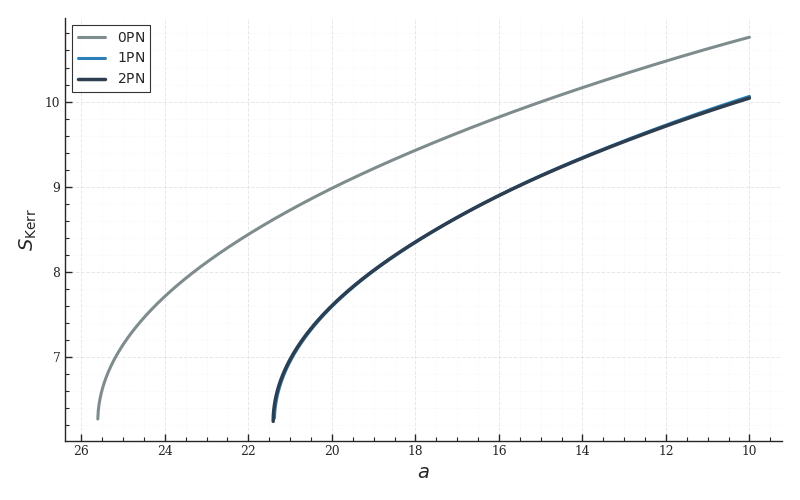

In [94]:
sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in"
})

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(a_prec, ENT_0PN, label=r"$0{\rm PN}$", color="#7f8c8d", lw=2.2)
ax.plot(a_prec, ENT_1PN, label=r"$1{\rm PN}$", color="#2980b9", lw=2.2)
ax.plot(a_prec, ENT_2PN, label=r"$2{\rm PN}$", color="#2c3e50", lw=2.5)

ax.invert_xaxis()

ax.set_xlabel(r"$a$")
ax.set_ylabel(r"$S_{\rm Kerr}$")

ax.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.45)
ax.minorticks_on()
ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.25)

ax.legend(
    frameon=True,
    shadow=False,
    fancybox=False,
    edgecolor="black",
    loc="best"
)

sns.despine()

plt.tight_layout()
plt.show()

PADE'

In [95]:
def fit_pade_2_1(
    x,
    y,
    sigma,
    y_scale=None,
    n_starts=10,
    random_seed=1234,
    loss="soft_l1",
    f_scale=1.0,
    max_nfev=30000,
    progress_label="Padé [2/1] fit"
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(sigma)
        & (sigma > 0)
    )

    x = x[valid]
    y = y[valid]
    sigma = sigma[valid]

    if len(x) < 10:
        raise RuntimeError(f"Too few valid points for {progress_label}: {len(x)}")

    if y_scale is None or not np.isfinite(y_scale) or y_scale == 0.0:
        y_scale = 1.0

    lower_bounds = np.array([-np.inf, -np.inf, -np.inf, 0.0], dtype=float)
    upper_bounds = np.array([ np.inf,  np.inf,  np.inf, np.inf], dtype=float)

    def residuals(params):
        y_model = pade_2_1(x, *params)
        res = (y_model - y) / sigma
        res = np.where(np.isfinite(res), res, 1.0e12)
        return res

    rng = np.random.default_rng(random_seed)

    starts = [
        np.array(
            [
                np.nanmedian(y),
                0.0,
                0.0,
                0.1
            ],
            dtype=float
        )
    ]

    for _ in range(n_starts - 1):
        starts.append(
            np.array(
                [
                    np.nanmedian(y),
                    rng.normal(loc=0.0, scale=0.2*y_scale),
                    rng.normal(loc=0.0, scale=0.2*y_scale),
                    rng.uniform(low=0.0, high=1.0)
                ],
                dtype=float
            )
        )

    best_result = None
    best_cost = np.inf
    last_exception = None

    iterator = tqdm(
        starts,
        desc=progress_label,
        total=len(starts),
        leave=True
    )

    for p0 in iterator:
        try:
            result = least_squares(
                residuals,
                p0,
                bounds=(lower_bounds, upper_bounds),
                loss=loss,
                f_scale=f_scale,
                x_scale="jac",
                max_nfev=max_nfev
            )

            if result.success and np.isfinite(result.cost) and result.cost < best_cost:
                best_result = result
                best_cost = result.cost

            iterator.set_postfix(best_cost=f"{best_cost:.3e}")

        except Exception as exc:
            last_exception = exc
            iterator.set_postfix(error=str(exc)[:40])
            continue

    if best_result is None:
        raise RuntimeError(
            "Padé [2/1] fit failed.\n"
            f"Last exception: {repr(last_exception)}"
        )

    return best_result.x, best_result


def run_pade_entropy_extrapolation(
    pn_label,
    a_arr,
    M_arr,
    J_arr,
    S_arr,
    m_ref,
    a_merger,
    a_extrap_max=15.0,
    a_extrap_min=1.0,
    n_extrap=10000,
    sigma_power=1.0,
    n_starts_Ebind=10,
    n_starts_chi=10
):
    a_arr = np.asarray(a_arr, dtype=float)
    M_arr = np.asarray(M_arr, dtype=float)
    J_arr = np.asarray(J_arr, dtype=float)
    S_arr = np.asarray(S_arr, dtype=float)

    valid_mask = (
        np.isfinite(S_arr)
        & np.isfinite(a_arr)
        & np.isfinite(M_arr)
        & np.isfinite(J_arr)
        & (a_arr > 0)
        & (M_arr > 0)
    )

    a_valid = a_arr[valid_mask]
    M_valid = M_arr[valid_mask]
    J_valid = J_arr[valid_mask]
    S_valid = S_arr[valid_mask]

    sort_idx = np.argsort(a_valid)

    a_fit = a_valid[sort_idx]
    M_fit = M_valid[sort_idx]
    J_fit = J_valid[sort_idx]
    S_fit = S_valid[sort_idx]

    x_fit = 1.0 / np.sqrt(a_fit)

    Ebind_fit = M_fit - m_ref
    chi_fit = J_fit / M_fit**2

    fit_mask = (
        np.isfinite(x_fit)
        & np.isfinite(Ebind_fit)
        & np.isfinite(chi_fit)
        & (np.abs(chi_fit) <= 1.0)
    )

    a_fit = a_fit[fit_mask]
    x_fit = x_fit[fit_mask]
    M_fit = M_fit[fit_mask]
    J_fit = J_fit[fit_mask]
    S_fit = S_fit[fit_mask]
    Ebind_fit = Ebind_fit[fit_mask]
    chi_fit = chi_fit[fit_mask]

    if len(x_fit) < 10:
        raise RuntimeError(f"Too few valid points for {pn_label}: {len(x_fit)}")

    a_min_fit = np.nanmin(a_fit)
    sigma_fit = (a_fit / a_min_fit)**sigma_power

    popt_Ebind, result_Ebind = fit_pade_2_1(
        x=x_fit,
        y=Ebind_fit,
        sigma=sigma_fit,
        y_scale=np.nanstd(Ebind_fit),
        n_starts=n_starts_Ebind,
        random_seed=1234,
        loss="soft_l1",
        f_scale=1.0,
        max_nfev=30000,
        progress_label=fr"{pn_label}: fitting $E_{{\rm bind}}$"
    )

    popt_chi, result_chi = fit_pade_2_1(
        x=x_fit,
        y=chi_fit,
        sigma=sigma_fit,
        y_scale=np.nanstd(chi_fit),
        n_starts=n_starts_chi,
        random_seed=4321,
        loss="soft_l1",
        f_scale=1.0,
        max_nfev=15000,
        progress_label=fr"{pn_label}: fitting $\chi$"
    )

    a_extrap = np.linspace(a_extrap_max, a_extrap_min, n_extrap)
    x_extrap = 1.0 / np.sqrt(a_extrap)

    Ebind_extrap = pade_2_1(x_extrap, *popt_Ebind)
    chi_extrap = pade_2_1(x_extrap, *popt_chi)

    M_extrap = m_ref + Ebind_extrap
    J_extrap = chi_extrap * M_extrap**2

    physical_mask = (
        np.isfinite(M_extrap)
        & np.isfinite(chi_extrap)
        & np.isfinite(J_extrap)
        & (M_extrap > 0)
        & (np.abs(chi_extrap) <= 1.0)
        & (np.abs(J_extrap) <= M_extrap**2)
    )

    ENT_extrap = np.full_like(a_extrap, np.nan, dtype=float)

    ENT_extrap[physical_mask] = entropy(
        M_extrap[physical_mask],
        J_extrap[physical_mask]
    )

    if np.all(np.isnan(ENT_extrap)):
        raise RuntimeError(
            f"The Padé [2/1] extrapolated curve for {pn_label} has no physical points."
        )

    idx_max = np.nanargmax(ENT_extrap)

    a_max_entropy = a_extrap[idx_max]
    S_max_entropy = ENT_extrap[idx_max]
    M_at_max = M_extrap[idx_max]
    J_at_max = J_extrap[idx_max]
    chi_at_max = chi_extrap[idx_max]
    delta_a = np.abs(a_max_entropy - a_merger)

    flags = []

    if idx_max == 0:
        flags.append("maximum_at_upper_boundary")

    if idx_max == len(a_extrap) - 1:
        flags.append("maximum_at_lower_boundary")

    if len(flags) == 0:
        flags.append("OK")

    result_row = {
        "PN_order": pn_label,
        "model": "Padé [2/1]",
        "a_max": a_max_entropy,
        "S_max": S_max_entropy,
        "M_at_max": M_at_max,
        "J_at_max": J_at_max,
        "chi_at_max": chi_at_max,
        "a_merger_NR": a_merger,
        "delta_a": delta_a,
        "cost_Ebind": result_Ebind.cost,
        "cost_chi": result_chi.cost,
        "nfev_Ebind": result_Ebind.nfev,
        "nfev_chi": result_chi.nfev,
        "flags": ", ".join(flags)
    }

    curve_dict = {
        "a_extrap": a_extrap,
        "x_extrap": x_extrap,
        "Ebind_extrap": Ebind_extrap,
        "M_extrap": M_extrap,
        "J_extrap": J_extrap,
        "chi_extrap": chi_extrap,
        "ENT_extrap": ENT_extrap,
        "popt_Ebind": popt_Ebind,
        "popt_chi": popt_chi,
        "result_Ebind": result_Ebind,
        "result_chi": result_chi,
        "physical_mask": physical_mask,
        "idx_max": idx_max
    }

    return result_row, curve_dict


try:
    m_ref = float(m1 + m2)
except NameError:
    try:
        m_ref = float(m1 + m2)
    except NameError:
        m_ref = 1.0


pade_inputs = {
    "0PN": {
        "a": a_prec,
        "M": E_tot_0PN,
        "J": J_tot_0PN,
        "S": ENT_0PN
    },
    "1PN": {
        "a": a_prec,
        "M": E_tot_1PN,
        "J": J_tot_1PN,
        "S": ENT_1PN
    },
    "2PN": {
        "a": a_prec,
        "M": E_tot_2PN,
        "J": J_tot_2PN,
        "S": ENT_2PN
    }
}

pade_results_all = []
pade_curves_all = {}

for pn_label, data in pade_inputs.items():
    result_row, curve_dict = run_pade_entropy_extrapolation(
        pn_label=pn_label,
        a_arr=data["a"],
        M_arr=data["M"],
        J_arr=data["J"],
        S_arr=data["S"],
        m_ref=m_ref,
        a_merger=a_merger,
        a_extrap_max=15.0,
        a_extrap_min=1.0,
        n_extrap=10000,
        sigma_power=1.0,
        n_starts_Ebind=5,
        n_starts_chi=5
    )

    pade_results_all.append(result_row)
    pade_curves_all[pn_label] = curve_dict

results_pade_all_df = pd.DataFrame(pade_results_all)

print("============================================================")
print("PADÉ [2/1] EXTRAPOLATION")
print("============================================================")

for _, row in results_pade_all_df.iterrows():
    print(f"  a_max      = {row['a_max']:.6f}")
    print(f"  a_merger   = {row['a_merger_NR']:.6f}")
    print(f"  Delta a    = {row['delta_a']:.6f}")
    print(f"  flags      = {row['flags']}")
    print("------------------------------------------------------------")



0PN: fitting $E_{\rm bind}$:   0%|          | 0/5 [00:00<?, ?it/s]

0PN: fitting $\chi$:   0%|          | 0/5 [00:00<?, ?it/s]

1PN: fitting $E_{\rm bind}$:   0%|          | 0/5 [00:00<?, ?it/s]

1PN: fitting $\chi$:   0%|          | 0/5 [00:00<?, ?it/s]

2PN: fitting $E_{\rm bind}$:   0%|          | 0/5 [00:00<?, ?it/s]

2PN: fitting $\chi$:   0%|          | 0/5 [00:00<?, ?it/s]

PADÉ [2/1] EXTRAPOLATION
  a_max      = 3.924892
  a_merger   = 3.133806
  Delta a    = 0.791087
  flags      = OK
------------------------------------------------------------
  a_max      = 3.140814
  a_merger   = 3.133806
  Delta a    = 0.007008
  flags      = OK
------------------------------------------------------------
  a_max      = 3.507651
  a_merger   = 3.133806
  Delta a    = 0.373845
  flags      = OK
------------------------------------------------------------


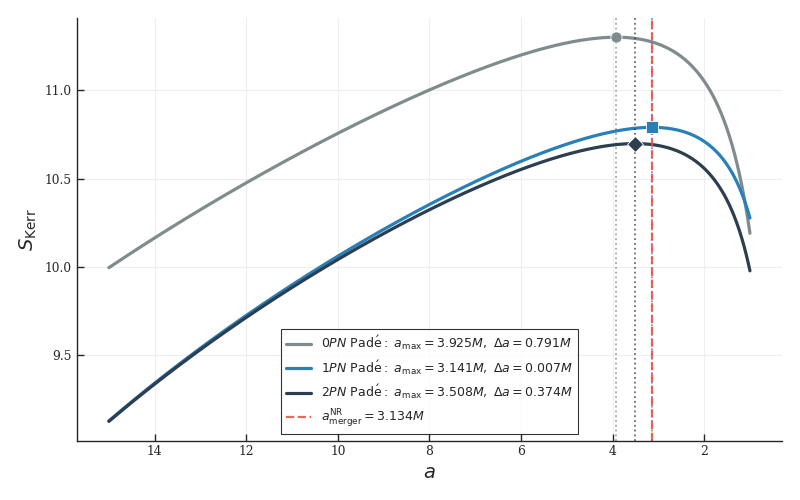

In [96]:
sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

colors = {"0PN": "#7f8c8d","1PN": "#2980b9","2PN": "#2c3e50"}
markers = {"0PN": "o","1PN": "s","2PN": "D"}

fig, ax = plt.subplots(figsize=(8, 5))

for pn_label in ["0PN", "1PN", "2PN"]:
    curve = pade_curves_all[pn_label]
    row = results_pade_all_df.loc[results_pade_all_df["PN_order"] == pn_label].iloc[0]
    a_extrap_i = curve["a_extrap"]
    ENT_extrap_i = curve["ENT_extrap"]
    a_max_i = row["a_max"]
    delta_a_i = row["delta_a"]
    sort_idx_i = np.argsort(a_extrap_i)
    a_sorted_i = a_extrap_i[sort_idx_i]
    ent_sorted_i = ENT_extrap_i[sort_idx_i]
    valid_i = np.isfinite(a_sorted_i) & np.isfinite(ent_sorted_i)
    y_at_max_i = np.interp(a_max_i,a_sorted_i[valid_i],ent_sorted_i[valid_i])
    ax.plot(a_extrap_i,ENT_extrap_i,color=colors[pn_label],lw=2.3,label=fr"${pn_label}\ \mathrm{{Pad\acute{{e}}}}:\ a_{{\max}}={a_max_i:.3f}M,\ \Delta a={delta_a_i:.3f}M$")
    ax.scatter(a_max_i,y_at_max_i,marker=markers[pn_label],s=65,color=colors[pn_label],zorder=5,edgecolor="white",linewidth=0.6)
    ax.axvline(a_max_i,color=colors[pn_label],linestyle=":",lw=1.3,alpha=0.75)

ax.axvline(a_merger,color="#e74c3c",linestyle="--",lw=1.6,alpha=0.85,label=fr"$a_{{\rm merger}}^{{\rm NR}}={a_merger:.3f}M$")
ax.invert_xaxis()
ax.set_xlabel(r"$a$")
ax.set_ylabel(r"$S_{\rm Kerr}$")
ax.legend(frameon=True,shadow=False,fancybox=False,edgecolor="black",loc="best")
sns.despine()
plt.tight_layout()
plt.show()

TAYLOR

In [97]:
def taylor_model_scaled(x, coeffs, x_center, x_scale):
    x = np.asarray(x, dtype=float)
    z = (x - x_center) / x_scale
    y = np.zeros_like(z, dtype=float)
    for k, ck in enumerate(coeffs):
        y += ck * z**k
    return y

def fit_taylor_scaled(
    x,
    y,
    sigma,
    degree=3,
    loss="soft_l1",
    f_scale=1.0,
    max_nfev=50000,
    progress_label="Taylor fit"
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    sigma = np.asarray(sigma, dtype=float)

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
        & np.isfinite(sigma)
        & (sigma > 0)
    )

    x = x[valid]
    y = y[valid]
    sigma = sigma[valid]

    if len(x) <= degree + 1:
        raise RuntimeError(
            f"Not enough points for Taylor degree {degree}: n_points = {len(x)}."
        )

    x_center = np.nanmean(x)
    x_scale = np.nanstd(x)

    if not np.isfinite(x_scale) or x_scale == 0.0:
        x_scale = 1.0

    z = (x - x_center) / x_scale

    poly_coeff_high_to_low = np.polyfit(
        z,
        y,
        deg=degree,
        w=1.0 / sigma
    )

    p0 = poly_coeff_high_to_low[::-1]

    def residuals(coeffs):
        y_model = taylor_model_scaled(
            x,
            coeffs,
            x_center=x_center,
            x_scale=x_scale
        )

        res = (y_model - y) / sigma
        res = np.where(np.isfinite(res), res, 1.0e12)

        return res

    result = least_squares(
        residuals,
        p0,
        loss=loss,
        f_scale=f_scale,
        x_scale="jac",
        max_nfev=max_nfev
    )

    if not result.success:
        raise RuntimeError(
            f"{progress_label} failed: {result.message}"
        )

    return result.x, x_center, x_scale, result

def run_taylor_entropy_extrapolation(
    pn_label,
    a_arr,
    M_arr,
    J_arr,
    S_arr,
    m_ref,
    a_merger,
    degree_Ebind=3,
    degree_chi=3,
    a_extrap_max=15.0,
    a_extrap_min=1.0,
    n_extrap=10000,
    sigma_power=1.0
):
    a_arr = np.asarray(a_arr, dtype=float)
    M_arr = np.asarray(M_arr, dtype=float)
    J_arr = np.asarray(J_arr, dtype=float)
    S_arr = np.asarray(S_arr, dtype=float)

    valid_mask = (
        np.isfinite(S_arr)
        & np.isfinite(a_arr)
        & np.isfinite(M_arr)
        & np.isfinite(J_arr)
        & (a_arr > 0)
        & (M_arr > 0)
    )

    a_valid = a_arr[valid_mask]
    M_valid = M_arr[valid_mask]
    J_valid = J_arr[valid_mask]
    S_valid = S_arr[valid_mask]

    sort_idx = np.argsort(a_valid)

    a_fit = a_valid[sort_idx]
    M_fit = M_valid[sort_idx]
    J_fit = J_valid[sort_idx]
    S_fit = S_valid[sort_idx]

    x_fit = 1.0 / np.sqrt(a_fit)

    Ebind_fit = M_fit - m_ref
    chi_fit = J_fit / M_fit**2

    fit_mask = (
        np.isfinite(x_fit)
        & np.isfinite(Ebind_fit)
        & np.isfinite(chi_fit)
        & (np.abs(chi_fit) <= 1.0)
    )

    a_fit = a_fit[fit_mask]
    x_fit = x_fit[fit_mask]
    M_fit = M_fit[fit_mask]
    J_fit = J_fit[fit_mask]
    S_fit = S_fit[fit_mask]
    Ebind_fit = Ebind_fit[fit_mask]
    chi_fit = chi_fit[fit_mask]

    if len(x_fit) < 20:
        raise RuntimeError(
            f"Too few valid points for a reliable Taylor fit for {pn_label}: {len(x_fit)}"
        )

    a_min_fit = np.nanmin(a_fit)
    sigma_fit = (a_fit / a_min_fit)**sigma_power

    coeff_Ebind, x_center_Ebind, x_scale_Ebind, result_Ebind = fit_taylor_scaled(
        x=x_fit,
        y=Ebind_fit,
        sigma=sigma_fit,
        degree=degree_Ebind,
        loss="soft_l1",
        f_scale=1.0,
        max_nfev=30000,
        progress_label=f"{pn_label}: fitting E_bind with Taylor"
    )

    coeff_chi, x_center_chi, x_scale_chi, result_chi = fit_taylor_scaled(
        x=x_fit,
        y=chi_fit,
        sigma=sigma_fit,
        degree=degree_chi,
        loss="soft_l1",
        f_scale=1.0,
        max_nfev=15000,
        progress_label=f"{pn_label}: fitting chi with Taylor"
    )

    a_extrap = np.linspace(a_extrap_max, a_extrap_min, n_extrap)
    x_extrap = 1.0 / np.sqrt(a_extrap)

    Ebind_extrap = taylor_model_scaled(
        x_extrap,
        coeff_Ebind,
        x_center=x_center_Ebind,
        x_scale=x_scale_Ebind
    )

    chi_extrap = taylor_model_scaled(
        x_extrap,
        coeff_chi,
        x_center=x_center_chi,
        x_scale=x_scale_chi
    )

    M_extrap = m_ref + Ebind_extrap
    J_extrap = chi_extrap * M_extrap**2

    physical_mask = (
        np.isfinite(M_extrap)
        & np.isfinite(chi_extrap)
        & np.isfinite(J_extrap)
        & (M_extrap > 0)
        & (np.abs(chi_extrap) <= 1.0)
        & (np.abs(J_extrap) <= M_extrap**2)
    )

    ENT_extrap = np.full_like(a_extrap, np.nan, dtype=float)

    ENT_extrap[physical_mask] = entropy(
        M_extrap[physical_mask],
        J_extrap[physical_mask]
    )

    if np.all(np.isnan(ENT_extrap)):
        raise RuntimeError(
            f"The Taylor-extrapolated curve for {pn_label} contains no valid physical points."
        )

    idx_max = np.nanargmax(ENT_extrap)

    a_max_entropy = a_extrap[idx_max]
    S_max_entropy = ENT_extrap[idx_max]
    M_at_max = M_extrap[idx_max]
    J_at_max = J_extrap[idx_max]
    chi_at_max = chi_extrap[idx_max]
    delta_a = np.abs(a_max_entropy - a_merger)

    flags = []

    if idx_max == 0:
        flags.append("maximum_at_upper_boundary")

    if idx_max == len(a_extrap) - 1:
        flags.append("maximum_at_lower_boundary")

    if not (np.nanmin(a_extrap) <= a_merger <= np.nanmax(a_extrap)):
        flags.append("a_merger_outside_extrapolation_range")

    if len(flags) == 0:
        flags.append("OK")

    result_row = {
        "PN_order": pn_label,
        "model": f"Taylor degree {degree_Ebind}",
        "degree_Ebind": degree_Ebind,
        "degree_chi": degree_chi,
        "a_max": a_max_entropy,
        "S_max": S_max_entropy,
        "M_at_max": M_at_max,
        "J_at_max": J_at_max,
        "chi_at_max": chi_at_max,
        "a_merger_NR": a_merger,
        "delta_a": delta_a,
        "cost_Ebind": result_Ebind.cost,
        "cost_chi": result_chi.cost,
        "nfev_Ebind": result_Ebind.nfev,
        "nfev_chi": result_chi.nfev,
        "flags": ", ".join(flags)
    }

    curve_dict = {
        "a_extrap": a_extrap,
        "x_extrap": x_extrap,
        "Ebind_extrap": Ebind_extrap,
        "M_extrap": M_extrap,
        "J_extrap": J_extrap,
        "chi_extrap": chi_extrap,
        "ENT_extrap": ENT_extrap,
        "coeff_Ebind": coeff_Ebind,
        "coeff_chi": coeff_chi,
        "x_center_Ebind": x_center_Ebind,
        "x_scale_Ebind": x_scale_Ebind,
        "x_center_chi": x_center_chi,
        "x_scale_chi": x_scale_chi,
        "result_Ebind": result_Ebind,
        "result_chi": result_chi,
        "physical_mask": physical_mask,
        "idx_max": idx_max
    }

    return result_row, curve_dict

try:
    m_ref = float(m1 + m2)
except NameError:
    try:
        m_ref = float(m1 + m2)
    except NameError:
        m_ref = 1.0

taylor_inputs = {
    "0PN": {
        "a": a_prec,
        "M": E_tot_0PN,
        "J": J_tot_0PN,
        "S": ENT_0PN
    },
    "1PN": {
        "a": a_prec,
        "M": E_tot_1PN,
        "J": J_tot_1PN,
        "S": ENT_1PN
    },
    "2PN": {
        "a": a_prec,
        "M": E_tot_2PN,
        "J": J_tot_2PN,
        "S": ENT_2PN
    }
}

taylor_results_all = []
taylor_curves_all = {}

for pn_label, data in taylor_inputs.items():
    result_row, curve_dict = run_taylor_entropy_extrapolation(
        pn_label=pn_label,
        a_arr=data["a"],
        M_arr=data["M"],
        J_arr=data["J"],
        S_arr=data["S"],
        m_ref=m_ref,
        a_merger=a_merger,
        degree_Ebind=3,
        degree_chi=3,
        a_extrap_max=15.0,
        a_extrap_min=1.0,
        n_extrap=10000,
        sigma_power=1.0
    )

    taylor_results_all.append(result_row)
    taylor_curves_all[pn_label] = curve_dict

results_taylor_all_df = pd.DataFrame(taylor_results_all)



print("============================================================")
print("TAYLOR EXTRAPOLATION ")
print("============================================================")

for _, row in results_taylor_all_df.iterrows():
    print(f"{row['PN_order']}:")
    print(f"  a_max      = {row['a_max']:.6f}")
    print(f"  a_merger   = {row['a_merger_NR']:.6f}")
    print(f"  Delta a    = {row['delta_a']:.6f}")
    print(f"  flags      = {row['flags']}")
    print("------------------------------------------------------------")

print("============================================================")

TAYLOR EXTRAPOLATION 
0PN:
  a_max      = 3.632263
  a_merger   = 3.133806
  Delta a    = 0.498458
  flags      = OK
------------------------------------------------------------
1PN:
  a_max      = 3.062406
  a_merger   = 3.133806
  Delta a    = 0.071399
  flags      = OK
------------------------------------------------------------
2PN:
  a_max      = 2.992399
  a_merger   = 3.133806
  Delta a    = 0.141406
  flags      = OK
------------------------------------------------------------


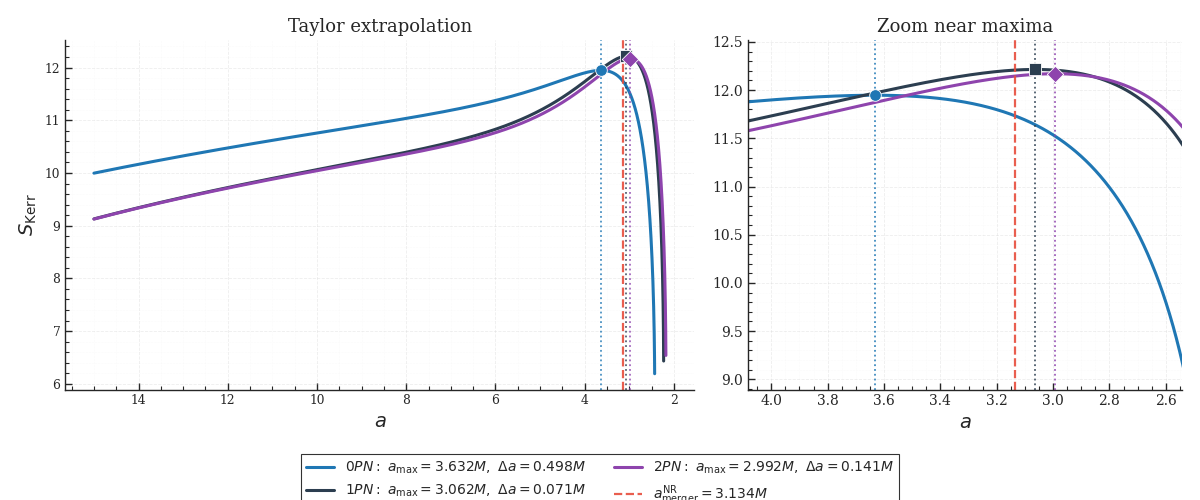

In [98]:
sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

pn_labels = ["0PN", "1PN", "2PN"]

curve_colors = {
    "0PN": "#1f77b4",
    "1PN": "#2c3e50",
    "2PN": "#8e44ad",
}

markers = {
    "0PN": "o",
    "1PN": "s",
    "2PN": "D",
}

fig, (ax, axz) = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    gridspec_kw={"width_ratios": [1.45, 1.0]}
)

curve_data = {}
focus_a_values = [a_merger]

for pn_label in pn_labels:
    row = results_taylor_all_df.loc[
        results_taylor_all_df["PN_order"] == pn_label
    ].iloc[0]

    a_taylor = taylor_curves_all[pn_label]["a_extrap"]
    ENT_taylor = taylor_curves_all[pn_label]["ENT_extrap"]

    a_max_taylor = row["a_max"]
    delta_a_taylor = row["delta_a"]

    sort_idx = np.argsort(a_taylor)
    a_sorted = a_taylor[sort_idx]
    ent_sorted = ENT_taylor[sort_idx]

    valid_interp_mask = np.isfinite(a_sorted) & np.isfinite(ent_sorted)

    a_sorted_valid = a_sorted[valid_interp_mask]
    ent_sorted_valid = ent_sorted[valid_interp_mask]

    y_at_max_taylor = np.interp(
        a_max_taylor,
        a_sorted_valid,
        ent_sorted_valid
    )

    curve_data[pn_label] = {
        "a": a_taylor,
        "ent": ENT_taylor,
        "a_sorted_valid": a_sorted_valid,
        "ent_sorted_valid": ent_sorted_valid,
        "a_max": a_max_taylor,
        "y_max": y_at_max_taylor,
        "delta_a": delta_a_taylor,
    }

    focus_a_values.append(a_max_taylor)

    label_i = (
        fr"${pn_label}:\ "
        fr"a_{{\max}}={a_max_taylor:.3f}M,\ "
        fr"\Delta a={delta_a_taylor:.3f}M$"
    )

    ax.plot(
        a_taylor,
        ENT_taylor,
        color=curve_colors[pn_label],
        lw=2.2,
        label=label_i
    )

    ax.scatter(
        a_max_taylor,
        y_at_max_taylor,
        marker=markers[pn_label],
        s=70,
        color=curve_colors[pn_label],
        zorder=5,
        edgecolor="white",
        linewidth=0.6
    )

    ax.axvline(
        a_max_taylor,
        color=curve_colors[pn_label],
        linestyle=":",
        lw=1.3,
        alpha=0.8
    )

ax.axvline(
    a_merger,
    color="#e74c3c",
    linestyle="--",
    lw=1.6,
    alpha=0.9,
    label=fr"$a_{{\rm merger}}^{{\rm NR}}={a_merger:.3f}M$"
)

ax.invert_xaxis()
ax.set_xlabel(r"$a$")
ax.set_ylabel(r"$S_{\rm Kerr}$")
ax.set_title("Taylor extrapolation")

a_focus_min = min(focus_a_values)
a_focus_max = max(focus_a_values)

x_margin = 0.45
x_low = a_focus_min - x_margin
x_high = a_focus_max + x_margin

y_focus_values = []

for pn_label in pn_labels:
    a_vals = curve_data[pn_label]["a_sorted_valid"]
    ent_vals = curve_data[pn_label]["ent_sorted_valid"]

    focus_mask = (a_vals >= x_low) & (a_vals <= x_high)

    y_focus_values.extend(ent_vals[focus_mask])

y_focus_values = np.asarray(y_focus_values, dtype=float)

ymin_focus = np.nanmin(y_focus_values)
ymax_focus = np.nanmax(y_focus_values)
y_margin = 0.10 * (ymax_focus - ymin_focus)

for pn_label in pn_labels:
    axz.plot(
        curve_data[pn_label]["a"],
        curve_data[pn_label]["ent"],
        color=curve_colors[pn_label],
        lw=2.2
    )

    axz.scatter(
        curve_data[pn_label]["a_max"],
        curve_data[pn_label]["y_max"],
        marker=markers[pn_label],
        s=70,
        color=curve_colors[pn_label],
        zorder=5,
        edgecolor="white",
        linewidth=0.6
    )

    axz.axvline(
        curve_data[pn_label]["a_max"],
        color=curve_colors[pn_label],
        linestyle=":",
        lw=1.3,
        alpha=0.85
    )

axz.axvline(
    a_merger,
    color="#e74c3c",
    linestyle="--",
    lw=1.6,
    alpha=0.9
)

axz.set_xlim(x_high, x_low)
axz.set_ylim(ymin_focus - y_margin, ymax_focus + y_margin)
axz.set_xlabel(r"$a$")
axz.set_title("Zoom near maxima")
axz.tick_params(axis="both", labelsize=10)

for axis in [ax, axz]:
    axis.minorticks_on()
    axis.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.35)
    axis.grid(True, which="minor", linestyle=":", linewidth=0.4, alpha=0.18)

handles, labels = ax.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    frameon=True,
    shadow=False,
    fancybox=False,
    edgecolor="black",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.04),
    ncol=2
)

sns.despine()

plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.show()